In [88]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output
import country_converter as coco
import numpy as np
import time
import re
from uncertainties import ufloat
import matplotlib.pyplot as plt
from uncertainties.unumpy import nominal_values, std_devs

In [89]:
def parse_ufloat(val):
    """Convert DataFrame cell into ufloat if possible."""
    from uncertainties import ufloat
    import re
    
    if isinstance(val, (int, float)):
        return ufloat(val, 0)
    if hasattr(val, "nominal_value"):  # already ufloat
        return val
    if isinstance(val, str):
        val = val.strip()
        # plain zeros
        if val in ["", "0", "0.0", "0.0+/-0.0", "0+/-0"]:
            return ufloat(0, 0)
        # match (a+/-b)e+exp
        m = re.match(r"\(([-+]?\d*\.?\d+)\+/-([-+]?\d*\.?\d+)\)e([-+]?\d+)", val)
        if m:
            nominal, error, exp = m.groups()
            return ufloat(float(nominal)*10**int(exp), float(error)*10**int(exp))
        # match (a+/-b)
        m2 = re.match(r"\(([-+]?\d*\.?\d+)\+/-([-+]?\d*\.?\d+)\)", val)
        if m2:
            return ufloat(float(m2.group(1)), float(m2.group(2)))
        # match plain float
        try:
            return ufloat(float(val), 0)
        except:
            return val
    return val



In [90]:
# ---  Load  data ---
file_path = "Scale_up_output_MS.csv"
df = pd.read_csv(file_path)

In [91]:
# Rename first column 
df.rename(columns={df.columns[0]: "Country"}, inplace=True)
df_conv = df.copy()
for col in df.columns[1:]:  # skip Country column
    df_conv[col] = df[col].apply(parse_ufloat)

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning:

Using UFloat objects with std_dev==0 may give unexpected results.



In [92]:
import country_converter as coco
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp

def parse_ufloat(val):
    """Convert string like '(8+/-4)e+06' into a ufloat. Leave NaN if fails."""
    try:
        return ufloat_fromstr(val) if isinstance(val, str) else val
    except Exception:
        return pd.NA

def ufloat_fromstr(s):
    """Parse uncertainties string format '(val+/-err)e+exp'."""
    # Example: (8+/-4)e+06
    if "+/-" in s:
        base, exp = s.split("e") if "e" in s else (s, "0")
        val, err = base.strip("()").split("+/-")
        return ufloat(float(val) * 10**int(exp), float(err) * 10**int(exp))
    else:
        return ufloat(float(s), 0)

def aggregate_by_region(df, region_type="UNregion"):
    """
    Aggregate countries into regions using country_converter.
    region_type can be 'UNregion', 'UNcontinent', etc.
    """
    cc = coco.CountryConverter()
    df = df.copy()

    # Add region column
    df["Region"] = cc.convert(names=df["Country"].tolist(), to=region_type)

    # Drop unmapped countries
    df = df[df["Region"] != "not found"]

    region_data = {}
    for region, group in df.groupby("Region"):
        # Drop non-time columns
        numeric = group.drop(columns=["Country", "Region"])

        # Convert every cell to ufloat
        numeric = numeric.map(parse_ufloat)

        # Elementwise sum across rows
        summed = numeric.apply(lambda col: sum([v for v in col if v is not pd.NA]), axis=0)

        region_data[region] = summed

    region_df = pd.DataFrame(region_data).T
    region_df = region_df.reset_index().rename(columns={"index": "Region"})

    return region_df


In [79]:

# ---------- Core Functions ----------

def get_country_series(df, country):
    """Return time (weeks), nominal values, and uncertainties for a single country."""
    row = df[df['Country'] == country].iloc[0, 1:]  # ignore country column
    time = np.arange(len(row))  # weeks index
    values = nominal_values(row.values.astype(object))
    errors = std_devs(row.values.astype(object))
    return time, values, errors


def plot_country(df, country, ax=None):
    """Plot a single country's series with uncertainty bands."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    t, vals, errs = get_country_series(df, country)
    ax.plot(t, vals, label=country)
    ax.fill_between(t, vals - errs, vals + errs, alpha=0.3)
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend()
    return ax


def plot_multiple_countries(df, countries):
    """Plot multiple countries together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for c in countries:
        plot_country(df, c, ax=ax)
    plt.title("Country series with uncertainty")
    plt.show()


# ---------- Aggregation by UN Region ----------

def plot_region(df, region, ax=None):
    """Plot aggregated UN region time series with uncertainty."""
    row = df[df['Region'] == region].iloc[0, 1:]
    t = np.arange(len(row))
    vals = nominal_values(row.values.astype(object))
    errs = std_devs(row.values.astype(object))
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    ax.plot(t, vals, label=region)
    ax.fill_between(t, vals - errs, vals + errs, alpha=0.3)
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend()
    return ax

def plot_multiple_regions(df, regions):
    """Plot multiple countries together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for r in regions:
        plot_region(df, r, ax=ax)
    plt.title("Region series with uncertainty")
    plt.show()

In [98]:
region_df['Region'].tolist()

['Australia and New Zealand',
 'Caribbean',
 'Central America',
 'Central Asia',
 'Eastern Africa',
 'Eastern Asia',
 'Eastern Europe',
 'Melanesia',
 'Micronesia',
 'Middle Africa',
 'Northern Africa',
 'Northern America',
 'Northern Europe',
 'Polynesia',
 'South America',
 'South-eastern Asia',
 'Southern Africa',
 'Southern Asia',
 'Southern Europe',
 'Western Africa',
 'Western Asia',
 'Western Europe']

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning:

Using UFloat objects with std_dev==0 may give unexpected results.

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning:

Using UFloat objects with std_dev==0 may give unexpected results.

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning:

Using UFloat objects with std_dev==0 may give unexpected results.

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning:

Using UFloat objects with std_dev==0 may give unexpected results.

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning:

Using UFloat objects with std_dev==0 may give unexpected results.

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning:

Using UFloat objects with std_dev==0 may give unexpected results.

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertaint

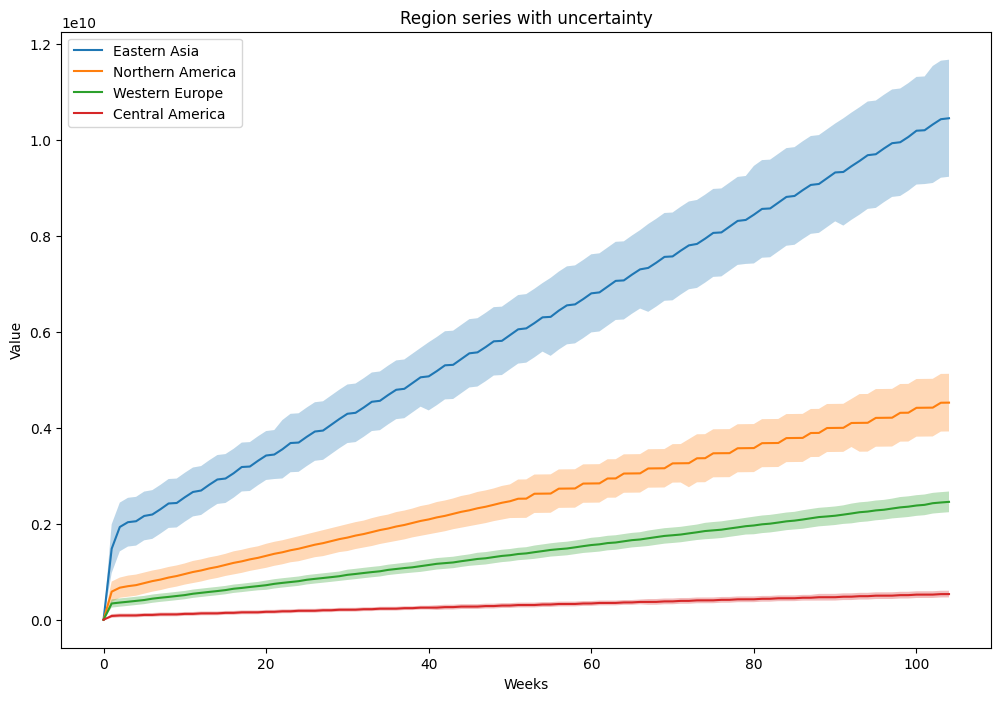

In [99]:
# Plot multiple
#plot_multiple_countries(df_conv, ["South Africa", "United States", "China"])

# Aggregate by UN regions
region_df = aggregate_by_region(df_conv, region_type="UNregion")

plot_multiple_regions(region_df, [ "Eastern Asia", "Northern America", "Western Europe", "Central America"])


In [97]:
#region_df['Region'].tolist()


100.0

In [86]:

# --- Safe cleaning function (keep exponent with e+03 etc.) ---
def clean_value(x):
    if isinstance(x, str):
        # Case: (2.0+/-1.1)e+05
        match = re.match(r"\(([\d\.]+)\+/-.*?\)(e[+-]?\d+)?", x)
        if match:
            base = match.group(1)
            exp = match.group(2) if match.group(2) else ""
            try:
                return float(base + exp)
            except:
                return np.nan
        # Case: 0.0+/-0
        match2 = re.match(r"([\d\.]+)\+/-", x)
        if match2:
            try:
                return float(match2.group(1))
            except:
                return np.nan
        # Case: plain number
        try:
            return float(x)
        except:
            return np.nan
    return x

week_cols = df.columns[2:]  
df[week_cols] = df[week_cols].applymap(clean_value)

df = df.copy()

# --- Accumulate airflow across weeks ---
df[week_cols] = df[week_cols].cumsum(axis=1)

# --- Add UN region + subregion + ISO3 ---
cc = coco.CountryConverter()
df["Region"] = cc.convert(names=df["Country"], to="UNregion")
df["Subregion"] = cc.convert(names=df["Country"], to="continent")  # fallback
df["ISO3"] = cc.convert(names=df["Country"], to="ISO3")

df_melt = df.melt(
    id_vars=["Country", "ISO3", "Region", "Subregion"],
    value_vars=week_cols,
    var_name="Week", value_name="AirFlow"
)

# --- color scale ---
vmin = df[week_cols].min().min()
vmax = df[week_cols].max().max()

# ---  Widgets ---
week_index = widgets.IntSlider(
    value=1,
    min=1,
    max=len(week_cols),
    step=1,
    description="Week:"
)

group_choice = widgets.Dropdown(
    options=["Region", "Subregion"],
    value="Region",
    description="Group by:"
)

region_filter = widgets.Dropdown(
    options=["All"] 
            + sorted(df["Region"].dropna().unique().tolist()) 
            + sorted(df["Subregion"].dropna().unique().tolist()),
    value="All",
    description="Filter:"
)

play_button = widgets.Button(
    description="▶ Play",
    tooltip="Auto-play weeks",
    button_style="success"
)

out = widgets.Output()

# --- Plotting ---
def update_plots(change=None):
    week = str(week_index.value)
    group = group_choice.value
    filter_value = region_filter.value
    
    with out:
        clear_output(wait=True)

        # Filter dataframe if region filter applied
        if filter_value != "All":
            df_filtered = df[(df["Region"] == filter_value) | (df["Subregion"] == filter_value)]
        else:
            df_filtered = df

        # Choropleth for cumulative airflow
        fig1 = px.choropleth(
            df_filtered,
            locations="ISO3",          
            locationmode="ISO-3",
            color=week,
            hover_name="Country",
            color_continuous_scale=[(0, "white"), (1, "darkgreen")],
            range_color=[vmin, vmax],
            title=f"Total Air Flow by Country (up to Week {week})"
        )
        fig1.show()

        # Historical line plot 
        fig2 = px.line(
            df_melt,
            x="Week", y="AirFlow", color=group,
            title=f"Total Air Flow by UN {group}"
        )
        fig2.update_layout(
            plot_bgcolor="#E6FFE6",   # chart area
        )
        fig2.show()

# ---  button logic ---
def play_clicked(b):
    for w in range(1, len(week_cols) + 1):
        week_index.value = w
        time.sleep(0.5)  # adjust playback speed 

play_button.on_click(play_clicked)


week_index.observe(update_plots, names="value")
group_choice.observe(update_plots, names="value")
region_filter.observe(update_plots, names="value")

from IPython.display import HTML
from ipywidgets import VBox

custom_style = """
<style>
#custom-container {
    background-color: #fffacd;   /* light yellow */
    padding: 15px;
    border-radius: 10px;
    margin-top: 10px;
    margin-bottom: 20px;
}
#custom-banner {
    width: 100%;
    background-color: #006400;   /* dark green */
    color: white;
    font-size: 24px;
    font-weight: bold;
    text-align: center;
    padding: 10px;
    border-radius: 6px;
    margin-bottom: 15px;
}
</style>
"""
display(HTML(custom_style))


container = widgets.VBox([
    widgets.HTML('<div id="custom-banner">ALLFED</div>'),
    week_index,
    group_choice,
    region_filter,
    play_button,
    out
])
container.layout = widgets.Layout(width="100%", padding="15px", border="solid 2px #006400", border_radius="10px", background_color="#fffacd")

display(container)


update_plots()


C:\Users\seabr\AppData\Local\Temp\ipykernel_24552\1061464442.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[week_cols] = df[week_cols].applymap(clean_value)
C:\Users\seabr\AppData\Local\Temp\ipykernel_24552\1061464442.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Region"] = cc.convert(names=df["Country"], to="UNregion")
C:\Users\seabr\AppData\Local\Temp\ipykernel_24552\1061464442.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Subregion"] = cc.convert(names=df["C